# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Dhanish Shah
* Username: dshah
* Student number: S6221785
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

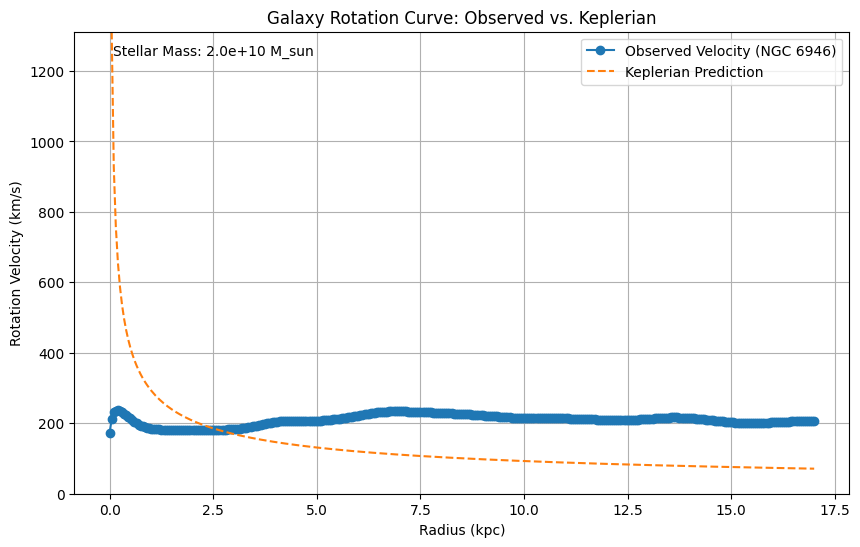

The observed rotation curve stays relatively flat at large radii instead of dropping off like the Keplerian curve, which indicates the presence of a dark matter halo.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

G = 4.30091e-6
M_stellar = 2e10

data = np.loadtxt('rotcur.dat')
radius = data[:, 0]
v_obs = data[:, 1]

with np.errstate(divide='ignore', invalid='ignore'):
    v_kepler = np.sqrt((G * M_stellar) / radius)
    v_kepler[radius == 0] = np.nan

np.savetxt('keplerian_curve.txt', np.column_stack((radius, v_kepler)))
kepler_data = np.loadtxt('keplerian_curve.txt')
r_k = kepler_data[:, 0]
v_k = kepler_data[:, 1]

#plotting
plt.figure(figsize=(10, 6))
plt.plot(radius, v_obs, label='Observed Velocity (NGC 6946)', marker='o', linestyle='-')
plt.plot(r_k, v_k, label='Keplerian Prediction', linestyle='--')

plt.xlabel('Radius (kpc)')
plt.ylabel('Rotation Velocity (km/s)')
plt.title('Galaxy Rotation Curve: Observed vs. Keplerian')
plt.ylim(0, np.nanmax(v_k[np.isfinite(v_k)]))
plt.legend()
plt.grid()
plt.annotate(f'Stellar Mass: {M_stellar:.1e} M_sun', xy=(0.05, 0.95), xycoords='axes fraction')
plt.show()

print("The observed rotation curve stays relatively flat at large radii instead of dropping off like the Keplerian curve, which indicates the presence of a dark matter halo.")

In [4]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

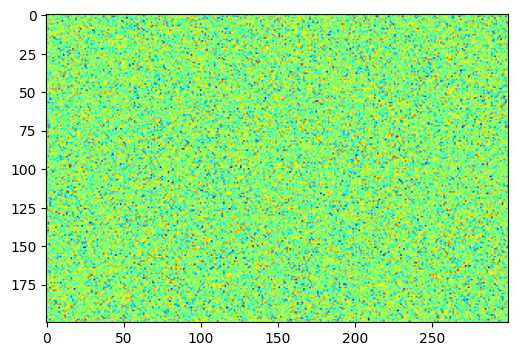

Slice Mean: -0.00020287179696205983
Slice Standard Deviation: 0.9731892859153397
Yes, the mean and standard deviation are close to 0 and 1.0 respectively, as expected from a sample drawn from this normal distribution.


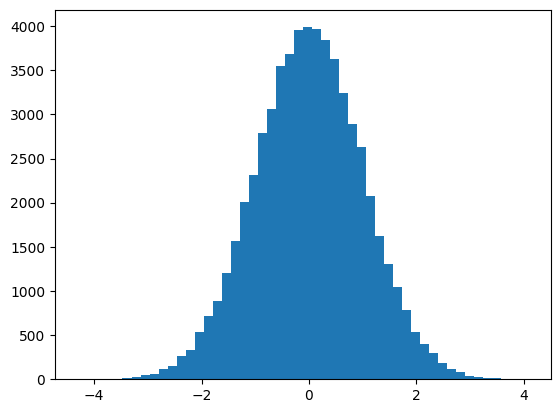

Gaussian distribution is observed.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

img_data = np.random.normal(loc=0.0, scale=1.0, size=(200, 300))

plt.figure(figsize=(8, 4))
plt.imshow(img_data, cmap='jet')
plt.show()

img_slice = img_data[100:130, 150:180]
slice_mean = np.mean(img_slice)
slice_std = np.std(img_slice)

print(f"Slice Mean: {slice_mean}")
print(f"Slice Standard Deviation: {slice_std}")
print("Yes, the mean and standard deviation are close to 0 and 1.0 respectively, as expected from a sample drawn from this normal distribution.")

plt.figure()
plt.hist(img_data.ravel(), bins=50)
plt.show()

print("Gaussian distribution is observed.")

In [6]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

18.84955592153876
15.865437575563961
AstroEllipse(Center: (0, 0), Axes: a=3, b=2, Angle: 0)


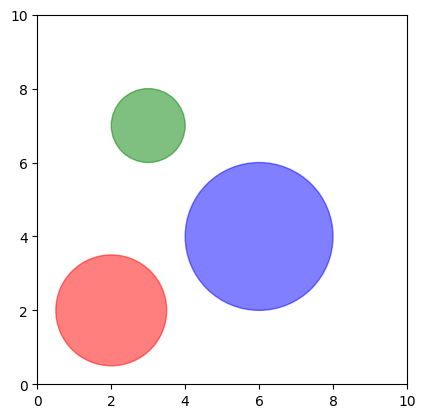

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
    def __init__(self, center, a, b, angle=0, **kwargs):
        super().__init__(xy=center, width=2*a, height=2*b, angle=angle, **kwargs)
        self.center_pos = center
        self.a = a
        self.b = b
        self.angle_val = angle

    def area(self):
        return np.pi * self.a * self.b

    def perimeter(self):
        return np.pi * (3 * (self.a + self.b) - np.sqrt((3 * self.a + self.b) * (self.a + 3 * self.b)))

    def __str__(self):
        return f"AstroEllipse(Center: {self.center_pos}, Axes: a={self.a}, b={self.b}, Angle: {self.angle_val})"

test_ellipse = AstroEllipse(center=(0, 0), a=3, b=2)
print(test_ellipse.area())
print(test_ellipse.perimeter())
print(test_ellipse)

class MyCircle(AstroEllipse):
    def __init__(self, center, radius, **kwargs):
        super().__init__(center, a=radius, b=radius, angle=0, **kwargs)

fig, ax = plt.subplots()
#example circles -
c1 = MyCircle((2, 2), 1.5, color='red', alpha=0.5)
c2 = MyCircle((6, 4), 2.0, color='blue', alpha=0.5)
c3 = MyCircle((3, 7), 1.0, color='green', alpha=0.5)

ax.add_patch(c1)
ax.add_patch(c2)
ax.add_patch(c3)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')

plt.show()

In [8]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

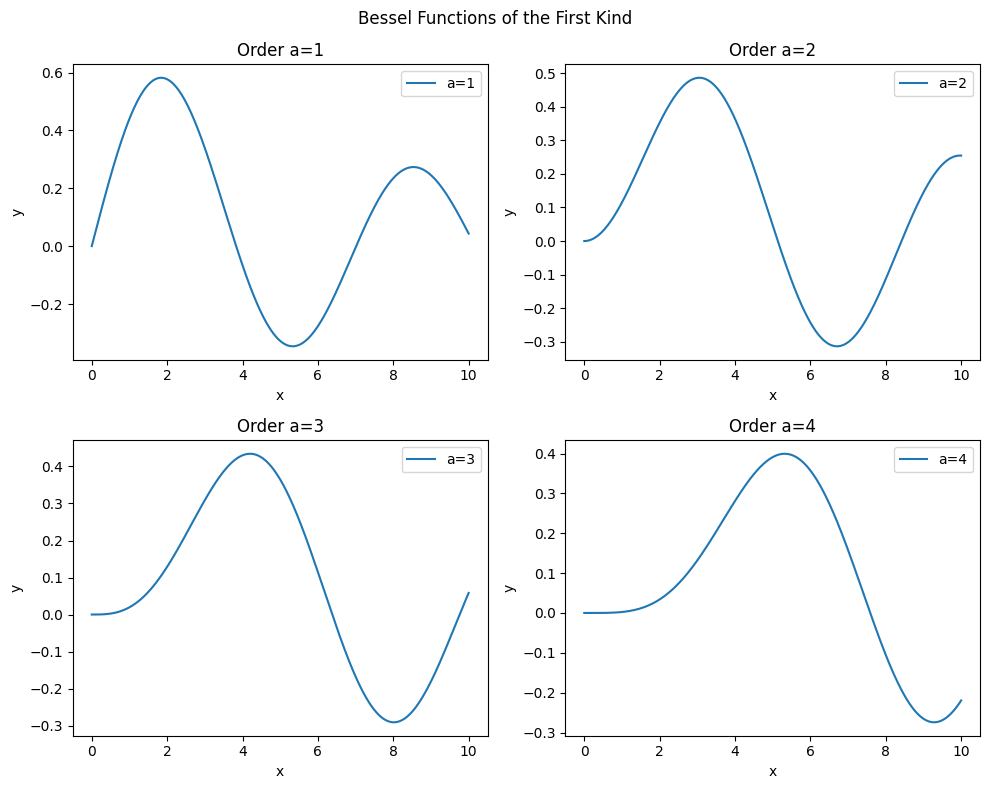

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

x = np.linspace(0, 10, 500)
a_values = [1, 2, 3, 4]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Bessel Functions of the First Kind")

for i, ax in enumerate(axs.flat):
    a = a_values[i]
    ax.plot(x, jv(a, x), label=f'a={a}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Order a={a}')
    ax.legend()

plt.tight_layout()
fig.savefig('bessel.png', transparent=True)
plt.show()

In [10]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

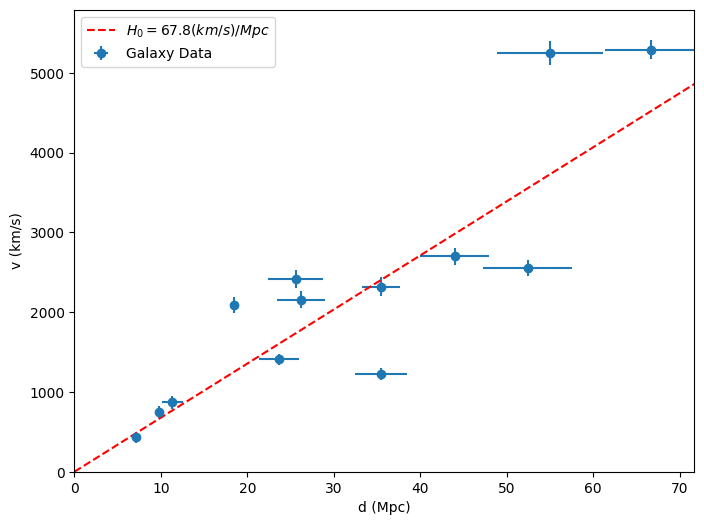

In [11]:
import numpy as np
import matplotlib.pyplot as plt
data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
d = data[0::4]
v = data[1::4]
err_d = data[2::4]
err_v = data[3::4]

H0 = 67.8 #given

fig, ax = plt.subplots(figsize=(8, 6)) #oo interface

ax.errorbar(d, v, xerr=err_d, yerr=err_v, fmt='o', label='Galaxy Data')

x_line = np.array([0, max(d) + 5])
y_line = H0 * x_line

ax.plot(x_line, y_line, color='red', linestyle='--', label=r'$H_0 = 67.8(km/s)/Mpc$')

ax.set_xlim(0, max(d) + 5)
ax.set_ylim(0, max(v) + 500)
ax.set_xlabel('d (Mpc)')
ax.set_ylabel('v (km/s)')
ax.legend()

plt.show()

In [12]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
